In [2]:
import numpy as np
import pandas as pd
import torch 
import cv2
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import os
import h5py
from tqdm import tqdm
from torchvision.io import read_video
import gc

In [3]:
VIDEO_BASE_PATH = r"E:\nexar_dataset\train"
OUTPUT_PATH = r"E:\nexar_dataset\processed_frames"

meta_pos = pd.read_csv(r"E:\nexar_dataset\metadata1.csv")
meta_neg = pd.read_csv(r"E:\nexar_dataset\metadata2.csv")

meta_pos["target"] = 1
meta_neg["target"] = 0

train = pd.concat([meta_pos, meta_neg], ignore_index=True)


In [6]:

train["video_path"] = train.apply(
    lambda row: os.path.join(
        VIDEO_BASE_PATH,
        "positive" if row["target"] == 1 else "negative",
        row["file_name"]
    ),
    axis=1
)

train["id"] = range(len(train))

print(" shape:", train.shape)
print(train.head())


 shape: (1500, 10)
   file_name  time_of_event  time_of_alert light_conditions weather  \
0  00822.mp4         19.500         18.633           Normal  Cloudy   
1  00208.mp4         19.800         19.233           Normal  Cloudy   
2  00072.mp4         20.101         20.068           Normal   Clear   
3  00128.mp4         19.267         18.333           Normal   Clear   
4  00205.mp4         21.146         18.196           Normal   Clear   

       scene  time_to_accident  target  \
0      Urban               NaN       1   
1  Sub-urban               NaN       1   
2      Urban               NaN       1   
3      Urban               NaN       1   
4    Highway               NaN       1   

                                  video_path  id  
0  E:\nexar_dataset\train\positive\00822.mp4   0  
1  E:\nexar_dataset\train\positive\00208.mp4   1  
2  E:\nexar_dataset\train\positive\00072.mp4   2  
3  E:\nexar_dataset\train\positive\00128.mp4   3  
4  E:\nexar_dataset\train\positive\00205.mp4  

In [11]:
pip install imageio imageio-ffmpeg


   ---------------------------------------- 0.0/22.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/22.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/22.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/22.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/22.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/22.6 MB ? eta -:--:--
    --------------------------------------- 0.5/22.6 MB 419.4 kB/s eta 0:00:53
    --------------------------------------- 0.5/22.6 MB 419.4 kB/s eta 0:00:53
   - -------------------------------------- 0.8/22.6 MB 493.7 kB/s eta 0:00:45
   - -------------------------------------- 0.8/22.6 MB 493.7 kB/s eta 0:00:45
   - -------------------------------------- 0.8/22.6 MB 493.7 kB/s eta 0:00:45
   - -------------------------------------- 0.8/22.6 MB 493.7 kB/s eta 0:00:45
   - -------------------------------------- 1.0/22.6 MB 445.6 kB/s eta 0:00:49
   - ----------------------

In [5]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pims

def get_frame_count(sample):
    path = sample["video_path"]
    cap = cv2.VideoCapture(path)
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()
    return total_frames

def get_fps(sample):
    path = sample["video_path"]
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    return fps

def get_frames_and_save(df, video_path, num_frames, output_path):
    os.makedirs(output_path, exist_ok=True)

    for i in range(df.shape[0]):
        sample = df.iloc[i]
        path = sample["video_path"]

        try:
            video = pims.Video(path)
        except Exception as e:
            print(f"error in opening file{path}: {e}")
            continue

        fps = sample["fps"]
        total_time = int(sample["total_frame"] / fps) if fps > 0 else 0

        if sample["target"] == 1:
            alert_time = sample.get("time_of_alert", 0) or 0
            event_time = sample.get("time_of_event", 0) or 0
            start_time = max(0, alert_time - 2)
            end_time = min(total_time, event_time + 2)
        else:
            mid_time = int(total_time) // 2
            start_time = max(0, mid_time - 5)
            end_time = min(total_time, mid_time + 5)

        start_frame = int(fps * start_time)
        end_frame = int(fps * end_time)
        step = max((end_frame - start_frame) // num_frames, 1)

        frames = []
        for frame_idx in range(start_frame, end_frame + 1, step):
            try:
                frame = video[int(frame_idx)]
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame_resized = cv2.resize(frame, (224, 224))
                frame_resized = frame_resized.astype("float32") / 255.0
                frame_tensor = torch.tensor(frame_resized).permute(2, 0, 1)
                frames.append(frame_tensor)
            except Exception as e:
                print(f"ERROR in frame {frame_idx} ({os.path.basename(path)}): {e}")
                continue

        valid_frames = [f for f in frames if isinstance(f, torch.Tensor) and f.shape == (3, 224, 224)]
        if len(valid_frames) == 0:
            print(f"no frame saved{path}")
            continue

        frames_np = torch.stack(valid_frames).numpy()
        np.save(os.path.join(output_path, str(int(sample["id"]))), frames_np)


train["total_frame"] = train.apply(get_frame_count, axis=1)
train["fps"] = train.apply(get_fps, axis=1)

train = train[(train["fps"] > 0) & (train["total_frame"] > 0)]
print("valid videos", len(train))

BATCH_SIZE = 200 
NUM_FRAMES = 10 
num_batches = (len(train) + BATCH_SIZE - 1) // BATCH_SIZE

print(f"🚀start processing{len(train)} video in {num_batches} batch ...\n")

for i in range(0, len(train), BATCH_SIZE):
    batch = train.iloc[i:i+BATCH_SIZE]
    batch_id = i // BATCH_SIZE + 1

    print(f"\n📦 Batch {batch_id}/{num_batches} | videos {i} to {i+len(batch)-1}")

    for j in tqdm(range(len(batch)), desc=f"🔹Processing Batch {batch_id}", ncols=100):
        single_df = batch.iloc[[j]] 
        get_frames_and_save(single_df, VIDEO_BASE_PATH, num_frames=NUM_FRAMES, output_path=OUTPUT_PATH)

    del batch
    gc.collect()

print("\n All videos processed and saved successfully!")

valid videos 1500
🚀start processing1500 video in 8 batch ...


📦 Batch 1/8 | videos 0 to 199


🔹Processing Batch 1: 100%|███████████████████████████████████████| 200/200 [06:27<00:00,  1.94s/it]



📦 Batch 2/8 | videos 200 to 399


🔹Processing Batch 2: 100%|███████████████████████████████████████| 200/200 [06:51<00:00,  2.06s/it]



📦 Batch 3/8 | videos 400 to 599


...


📦 Batch 7/8 | videos 1200 to 1399


🔹Processing Batch 7: 100%|███████████████████████████████████████| 200/200 [07:41<00:00,  2.31s/it]



📦 Batch 8/8 | videos 1400 to 1499


🔹Processing Batch 8: 100%|███████████████████████████████████████| 100/100 [03:27<00:00,  2.07s/it]



 All videos processed and saved successfully!


some files: ['0.npy', '1.npy', '10.npy', '100.npy', '1000.npy']
 array shape (11, 3, 224, 224)
 type: float32


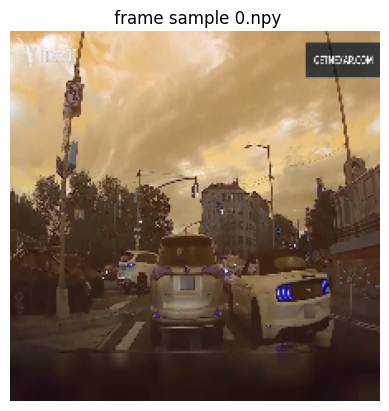

In [9]:
import matplotlib.pyplot as plt

files = [f for f in os.listdir(OUTPUT_PATH) if f.endswith(".npy")]
print("some files:", files[:5])

sample_path = os.path.join(OUTPUT_PATH, files[0])
frames = np.load(sample_path)

print(" array shape", frames.shape)
print(" type:", frames.dtype)

frame = frames[0] 
frame_rgb = np.transpose(frame, (1, 2, 0))  # turn to (224, 224, 3)

plt.imshow(frame_rgb)
plt.title(f" frame sample {files[0]}")
plt.axis("off")
plt.show()

In [11]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(train, test_size=0.2, random_state=42, shuffle=True, stratify=train["target"])

class CrashFrameDataset(Dataset):
    def __init__(self, df, frames_dir):
        self.df = df.reset_index(drop=True)
        self.frames_dir = frames_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        sample = self.df.iloc[idx]
        video_id = int(sample["id"])
        target = int(sample["target"])
        npy_path = os.path.join(self.frames_dir, f"{video_id}.npy")

        # load numpy frames
        frames = np.load(npy_path)  # (10, 3, 224, 224)
        frames = torch.tensor(frames, dtype=torch.float32)

        return frames, target

FRAMES_PATH = r"E:\nexar_dataset\processed_frames"

train_dataset = CrashFrameDataset(X_train, FRAMES_PATH)
val_dataset   = CrashFrameDataset(X_test, FRAMES_PATH)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0)

print(f"Train videos: {len(train_dataset)}, Validation videos: {len(val_dataset)}")


Train videos: 1200, Validation videos: 300


In [12]:
import torch
import torch.nn as nn
import torchvision.models as models

class CrashDetectionModel(nn.Module):
    def __init__(self, num_classes=2, hidden_size=256):
        super(CrashDetectionModel, self).__init__()

        self.feature_extractor = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.feature_extractor.classifier = nn.Identity() 

        for param in self.feature_extractor.parameters():
            param.requires_grad = False

        self.pre_lstm = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.lstm = nn.LSTM(input_size=512, hidden_size=hidden_size, num_layers=1, batch_first=True)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        #  (B, T, 3, 224, 224)
        B, T, C, H, W = x.shape

        features = []
        for t in range(T):
            frame = x[:, t, :, :, :]
            out = self.feature_extractor(frame) 
            features.append(out)

        features = torch.stack(features, dim=1)  # (B, T, 1280)
        features = self.pre_lstm(features)        # (B, T, 512)

        lstm_out, _ = self.lstm(features)
        last_output = lstm_out[:, -1, :]         
        out = self.classifier(last_output)
        return out


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CrashDetectionModel().to(device)

frames, labels = next(iter(train_loader))
frames = frames.to(device)
labels = torch.tensor(labels, dtype=torch.long).to(device)

print(" Batch shape:", frames.shape)

outputs = model(frames)
print("Model output shape:", outputs.shape)


C:\Users\Asus\AppData\Local\Temp\ipykernel_4340\4006963200.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.long).to(device)


 Batch shape: torch.Size([2, 11, 3, 224, 224])
Model output shape: torch.Size([2, 2])


In [15]:

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())


CUDA available: True
GPU name: NVIDIA GeForce RTX 4050 Laptop GPU
Current device index: 0


In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

model = CrashDetectionModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 10

for epoch in range(num_epochs):
    print(f"\n Epoch {epoch+1}/{num_epochs}")
    model.train()
    running_loss = 0.0

    for frames, labels in tqdm(train_loader, desc=f"Training Epoch {epoch+1}", ncols=100):
        frames = frames.to(device)
        if not isinstance(labels, torch.Tensor):
            labels = torch.tensor(labels, dtype=torch.long)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(frames)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        del frames, labels
        torch.cuda.empty_cache()

    avg_train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for frames, labels in val_loader:
            frames = frames.to(device)
            if not isinstance(labels, torch.Tensor):
                labels = torch.tensor(labels, dtype=torch.long)
            labels = labels.to(device)

            outputs = model(frames)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            del frames, labels
            torch.cuda.empty_cache()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")


 Using device: cuda

 Epoch 1/10


Training Epoch 1: 100%|███████████████████████████████████████████| 600/600 [03:50<00:00,  2.60it/s]


Epoch 1/10 | Train Loss: 0.6992 | Val Loss: 0.6901 | Val Acc: 0.5000

 Epoch 2/10


Training Epoch 2: 100%|███████████████████████████████████████████| 600/600 [03:34<00:00,  2.80it/s]


Epoch 2/10 | Train Loss: 0.6932 | Val Loss: 0.6669 | Val Acc: 0.6467

 Epoch 3/10


...

Epoch 8/10 | Train Loss: 0.6338 | Val Loss: 0.5888 | Val Acc: 0.6833

 Epoch 9/10


Training Epoch 9: 100%|███████████████████████████████████████████| 600/600 [03:23<00:00,  2.95it/s]


Epoch 9/10 | Train Loss: 0.6521 | Val Loss: 0.6027 | Val Acc: 0.6733

 Epoch 10/10


Training Epoch 10: 100%|██████████████████████████████████████████| 600/600 [03:22<00:00,  2.96it/s]


Epoch 10/10 | Train Loss: 0.6340 | Val Loss: 0.6370 | Val Acc: 0.7033


In [19]:
save_path = r"E:\nexar_dataset\models\crash_model_efficientnet_lstm.pth"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save({
    'epoch': epoch + 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_acc': val_acc,
    'val_loss': avg_val_loss
}, save_path)

print(f"model saved \n{save_path}")


model saved 
E:\nexar_dataset\models\crash_model_efficientnet_lstm.pth
